#Import Libraries & Loading the dataset

In [ ]:
# Access the files from google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

# to compute distances
from scipy.spatial.distance import pdist

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet


# to perform PCA
from sklearn.decomposition import PCA

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# To supress warnings
import warnings

warnings.filterwarnings("ignore")


# Read the dataset
data = pd.read_excel('/content/drive/My Drive/Credit Card Customer Data.xlsx')
print(data)

Mounted at /content/drive
     Sl_No  Customer Key  Avg_Credit_Limit  Total_Credit_Cards  \
0        1         87073            100000                   2   
1        2         38414             50000                   3   
2        3         17341             50000                   7   
3        4         40496             30000                   5   
4        5         47437            100000                   6   
..     ...           ...               ...                 ...   
655    656         51108             99000                  10   
656    657         60732             84000                  10   
657    658         53834            145000                   8   
658    659         80655            172000                  10   
659    660         80150            167000                   9   

     Total_visits_bank  Total_visits_online  Total_calls_made  
0                    1                    1                 0  
1                    0                   10          

In [ ]:
df = data.copy()

#Overview of the dataset

In [ ]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
df.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


In [ ]:
df.shape

(660, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().value_counts()

,,,,,,,count
Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,
False,False,False,False,False,False,False,660


In [ ]:
df['Sl_No'].nunique()

660

In [ ]:
df['Customer Key'].nunique()

655

In [ ]:
df['Customer Key'].duplicated().sum()

np.int64(5)

In [ ]:
df.loc[df["Customer Key"].duplicated(keep=False), :].sort_values(by="Customer Key", ascending=False)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
632,633,97935,187000,7,1,7,0
104,105,97935,17000,2,1,2,10
398,399,96929,67000,6,2,2,2
391,392,96929,13000,4,5,0,0
541,542,50706,60000,7,5,2,2
411,412,50706,44000,4,5,0,2
332,333,47437,17000,7,3,1,0
4,5,47437,100000,6,0,12,3
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2


In [ ]:
df = df[~df['Customer Key'].duplicated(keep='first')].copy()

In [ ]:
df['Customer Key'].duplicated().sum()

np.int64(0)

In [ ]:
df.drop('Customer Key',axis=1,inplace=True)

In [ ]:
df.drop('Sl_No',axis=1,inplace=True)

In [ ]:
df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,655.0,34242.748092,37240.896986,3000.0,10000.0,18000.0,48000.0,200000.0
Total_Credit_Cards,655.0,4.691603,2.169325,1.0,3.0,5.0,6.0,10.0
Total_visits_bank,655.0,2.401527,1.633648,0.0,1.0,2.0,4.0,5.0
Total_visits_online,655.0,2.606107,2.940380,0.0,1.0,2.0,4.0,15.0
Total_calls_made,655.0,3.601527,2.867352,0.0,1.0,3.0,5.0,10.0


#Univariate Analysis

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def histogram_boxplot(data,feature,figsize=(15, 10),kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

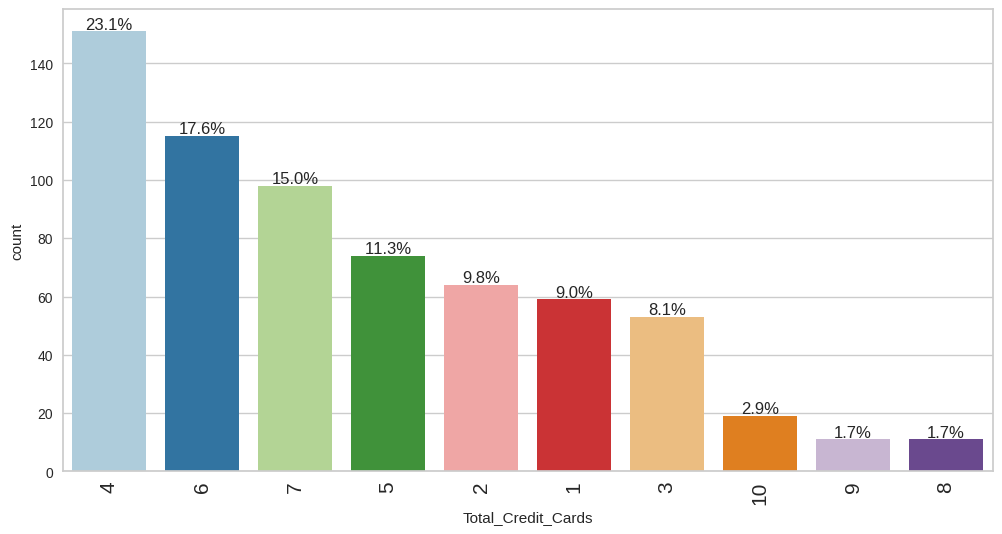

In [ ]:
labeled_barplot(df, 'Total_Credit_Cards', perc=True)

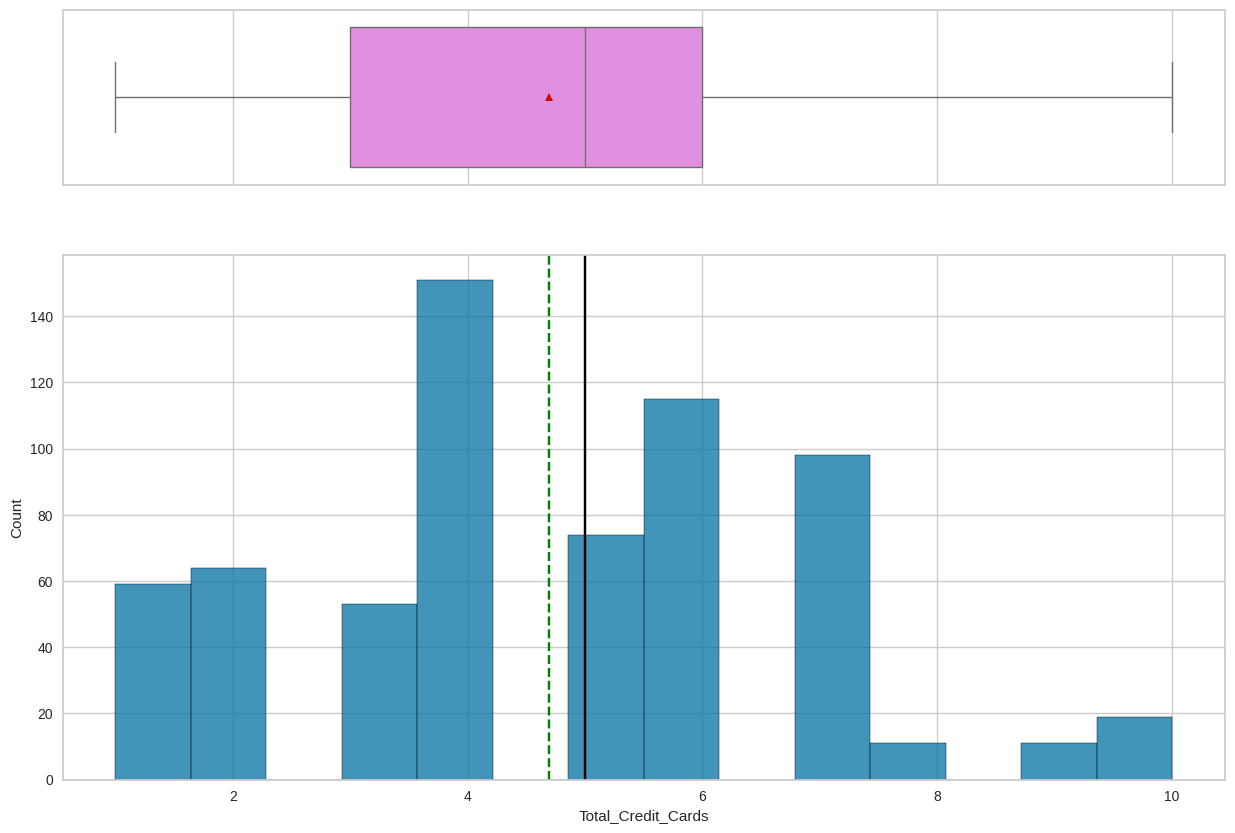

In [ ]:
histogram_boxplot(df, 'Total_Credit_Cards')

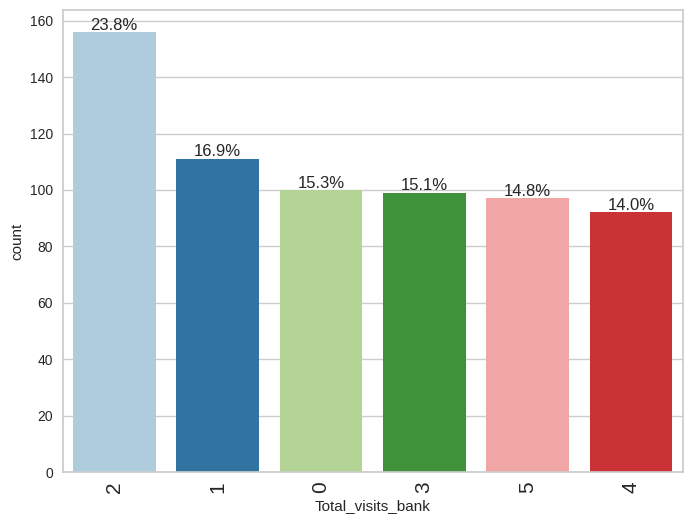

In [ ]:
labeled_barplot(df, 'Total_visits_bank', perc=True)

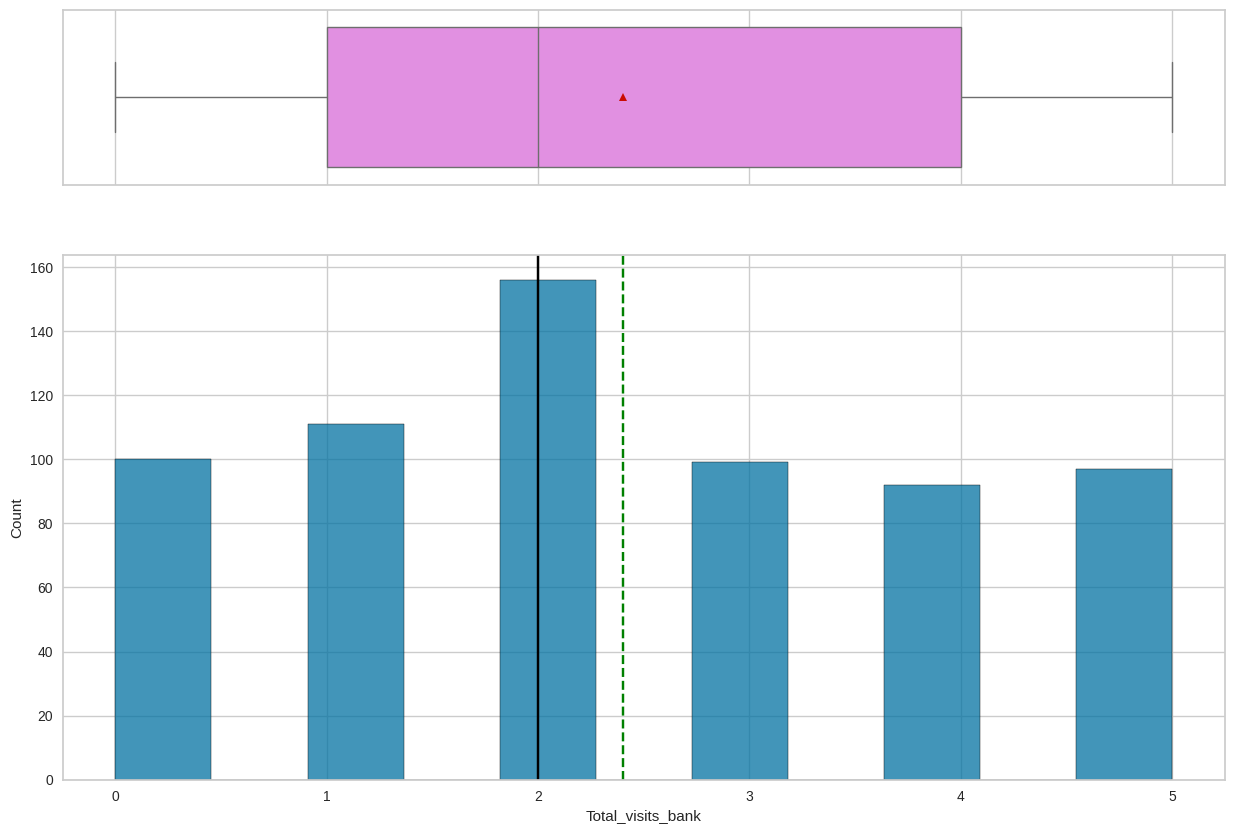

In [ ]:
histogram_boxplot(df, 'Total_visits_bank')

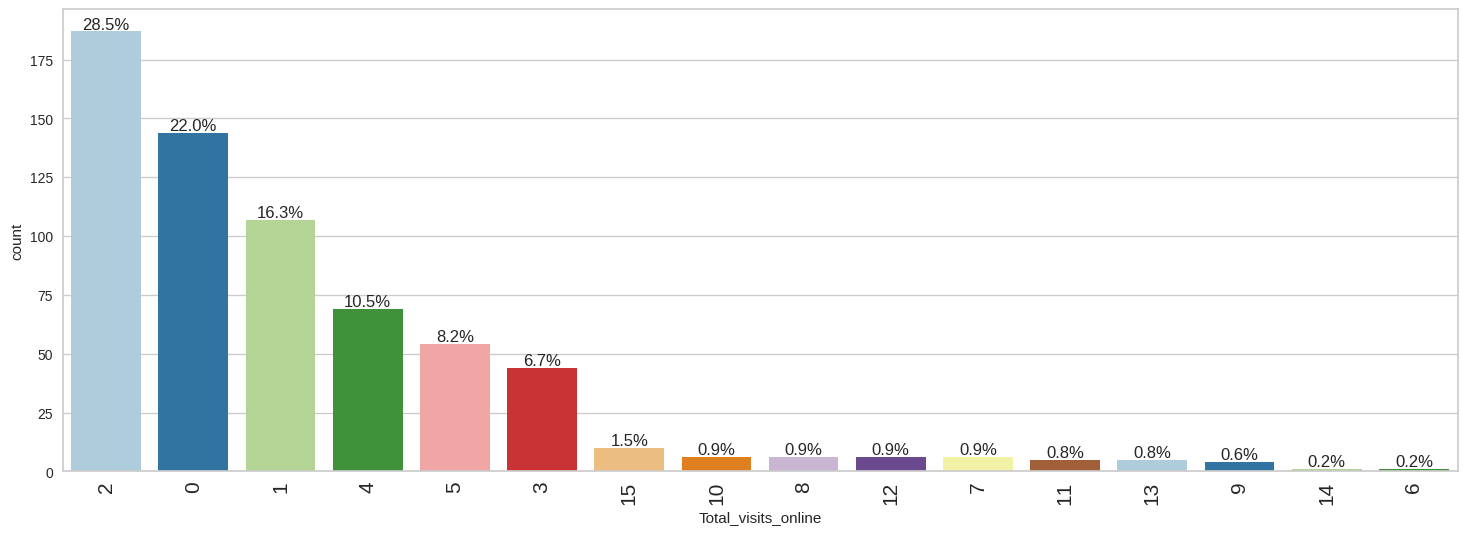

In [ ]:
labeled_barplot(df, 'Total_visits_online', perc=True)

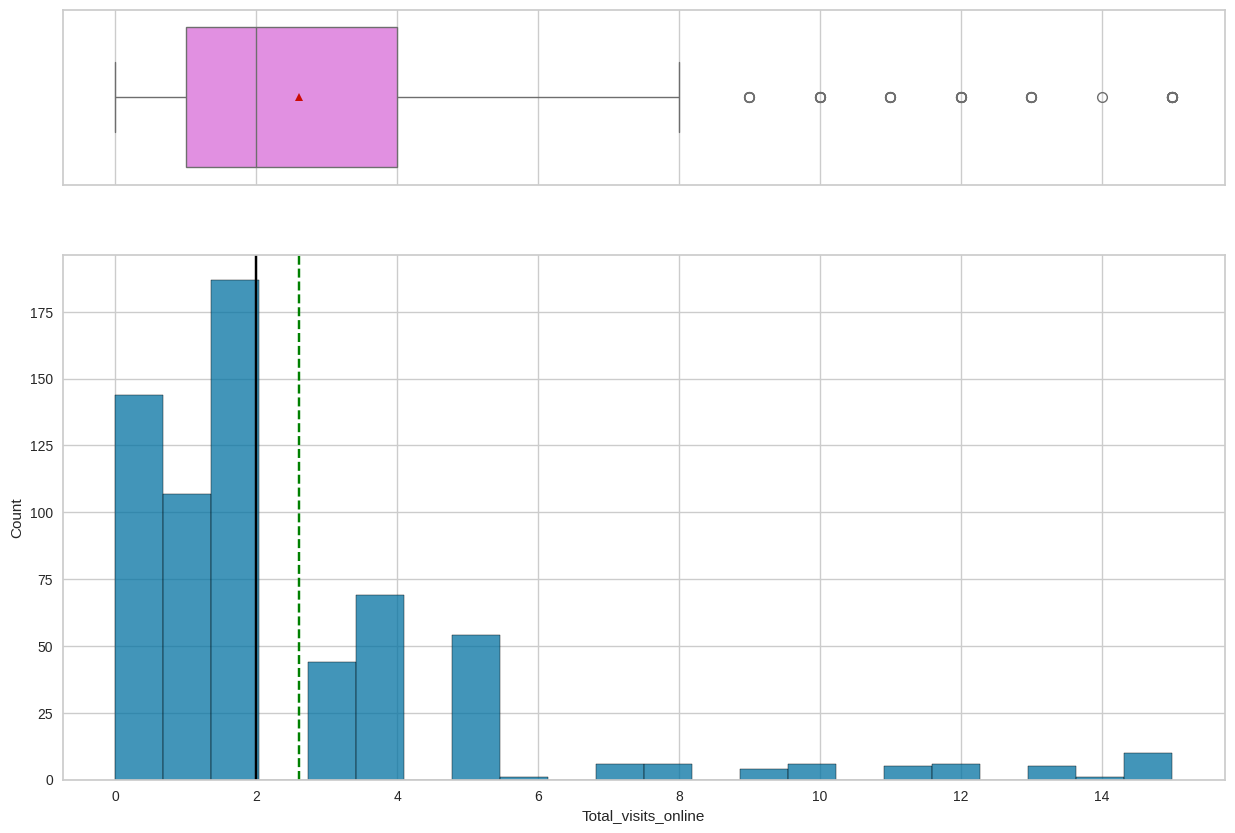

In [ ]:
histogram_boxplot(df, 'Total_visits_online')

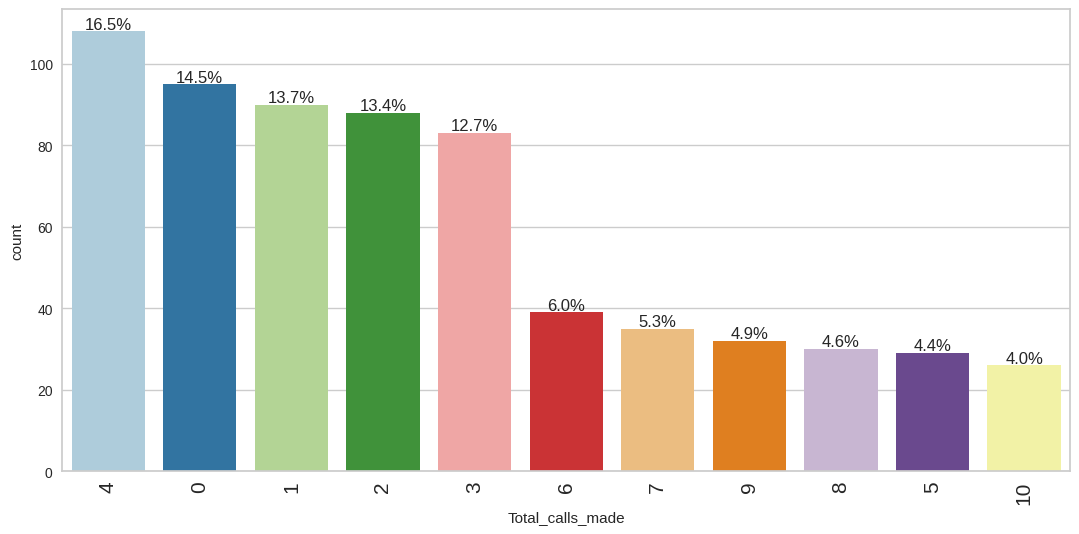

In [ ]:
labeled_barplot(df, 'Total_calls_made', perc=True)

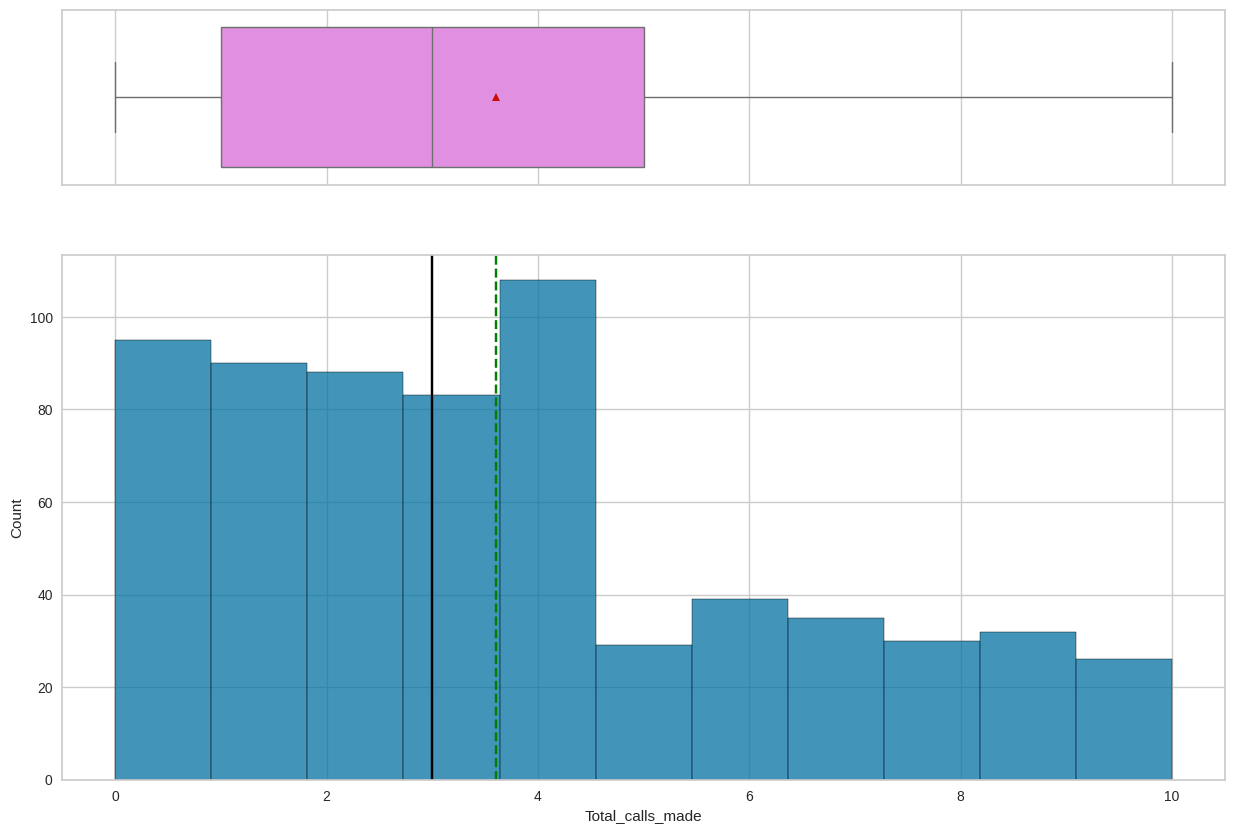

In [ ]:
histogram_boxplot(df, 'Total_calls_made')

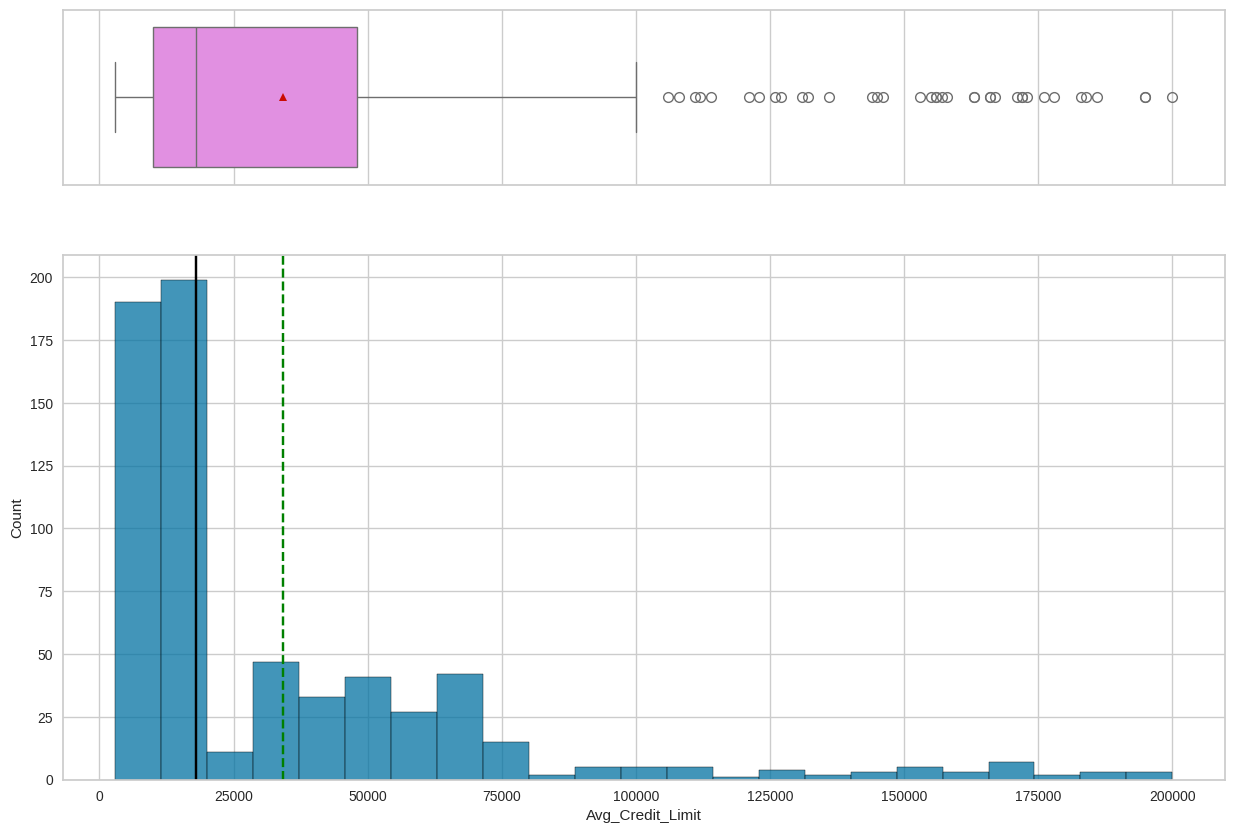

In [ ]:
histogram_boxplot(df, 'Avg_Credit_Limit')

#Bivariate Analysis

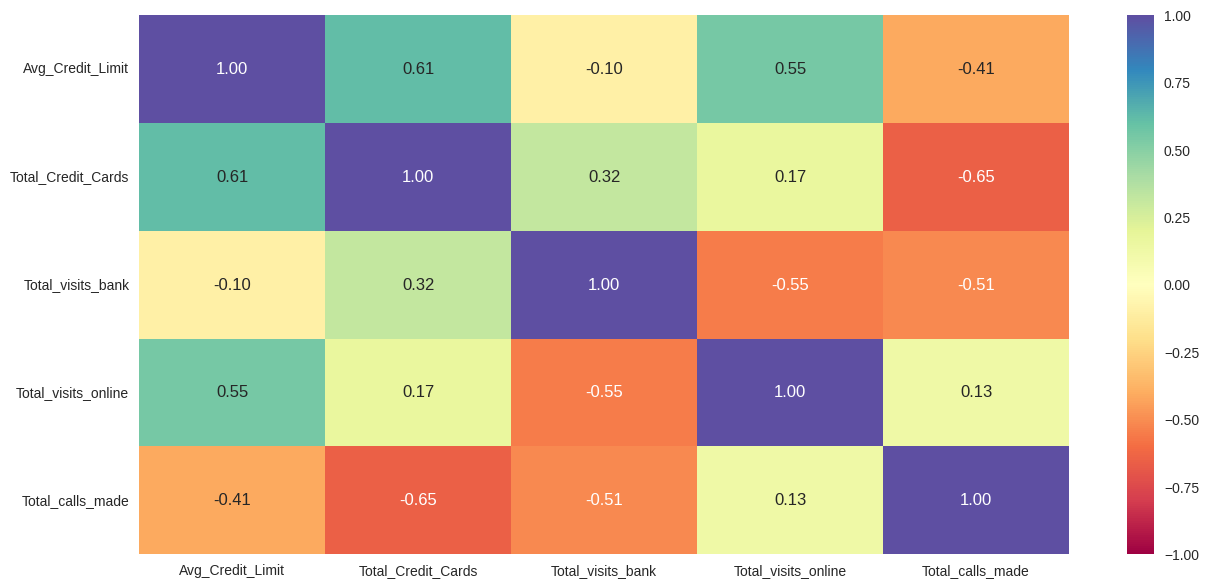

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

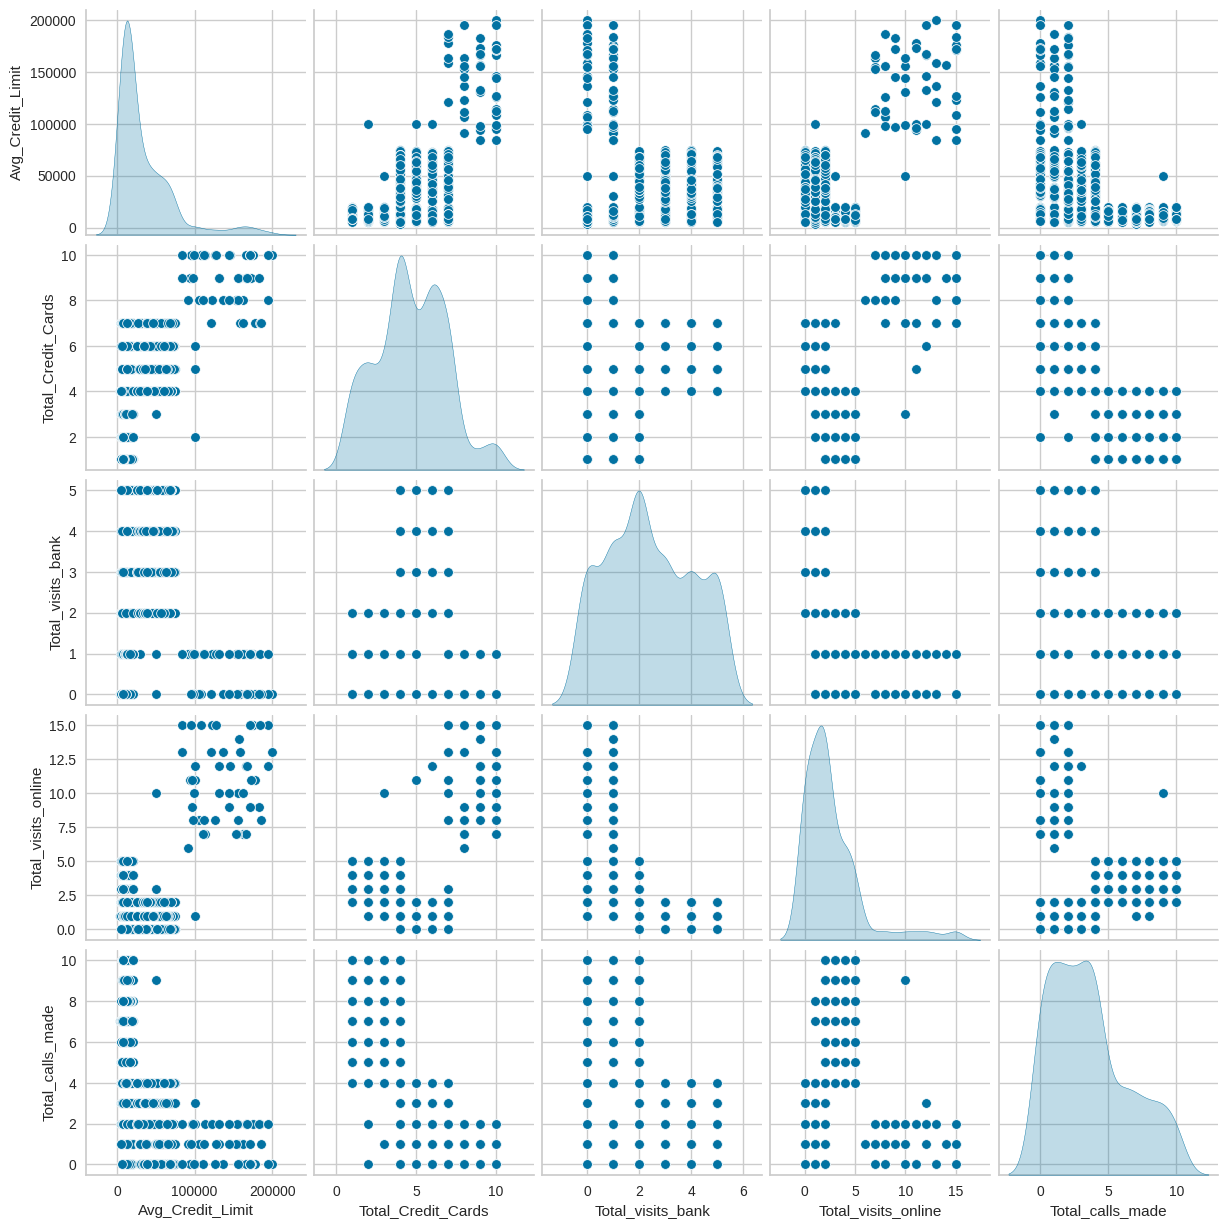

In [ ]:
sns.pairplot(data=df,diag_kind="kde")
plt.show()

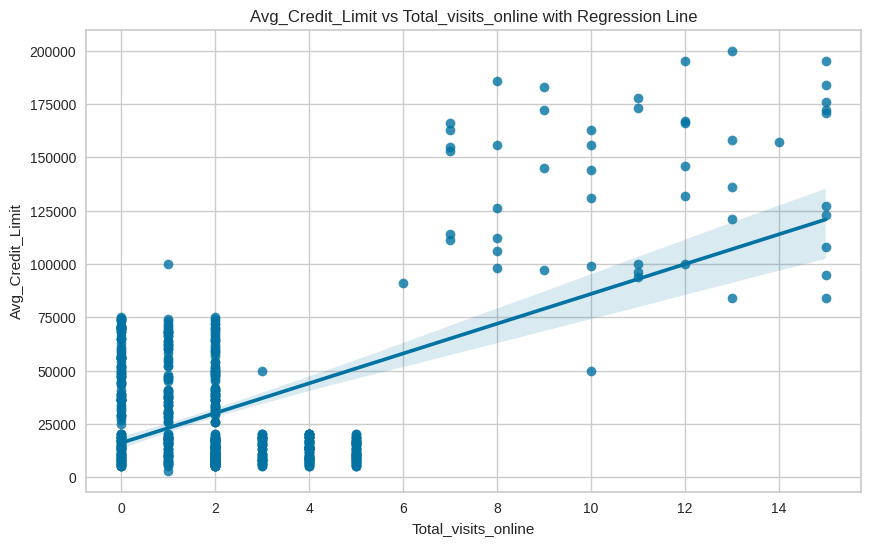

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Total_visits_online', y='Avg_Credit_Limit')
plt.title('Avg_Credit_Limit vs Total_visits_online with Regression Line')
plt.xlabel('Total_visits_online')
plt.ylabel('Avg_Credit_Limit')
plt.show()

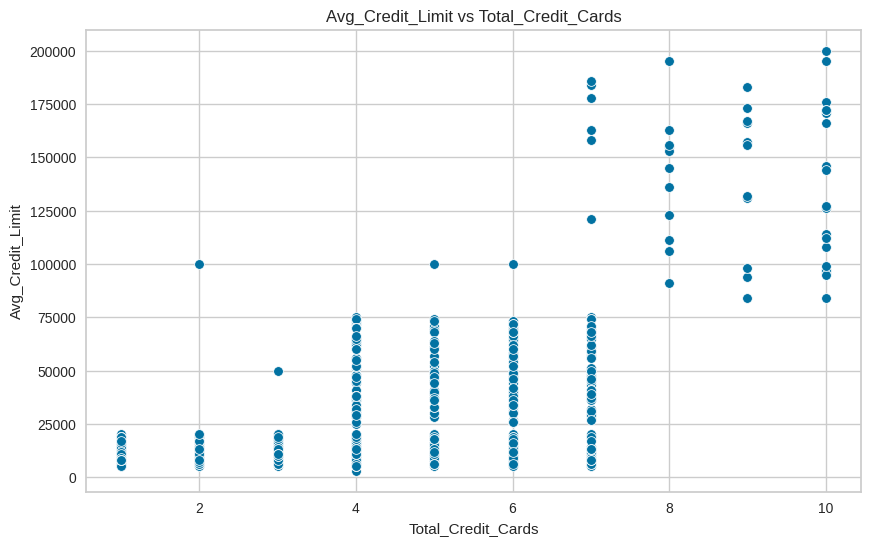

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_Credit_Cards', y='Avg_Credit_Limit')
plt.title('Avg_Credit_Limit vs Total_Credit_Cards')
plt.xlabel('Total_Credit_Cards')
plt.ylabel('Avg_Credit_Limit')
plt.show()

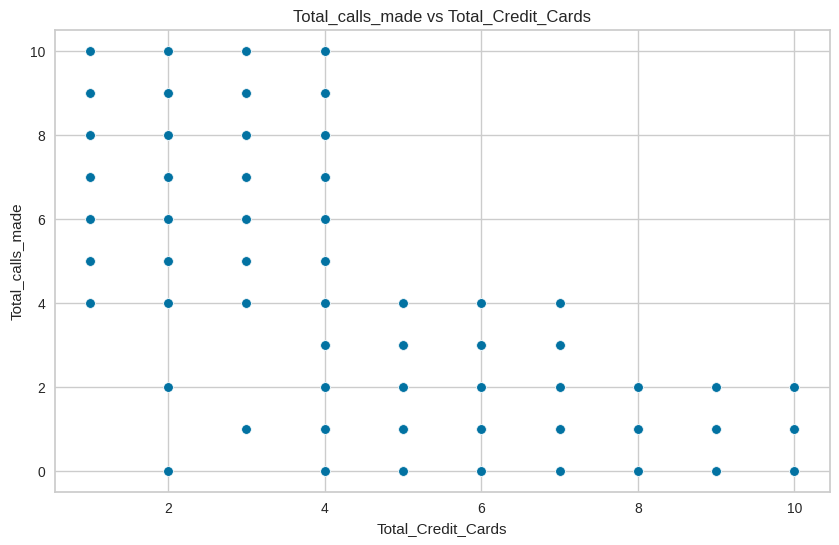

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_Credit_Cards', y='Total_calls_made')
plt.title('Total_calls_made vs Total_Credit_Cards')
plt.xlabel('Total_Credit_Cards')
plt.ylabel('Total_calls_made')
plt.show()

Text(0, 0.5, 'Avg of Total_visits_bank')

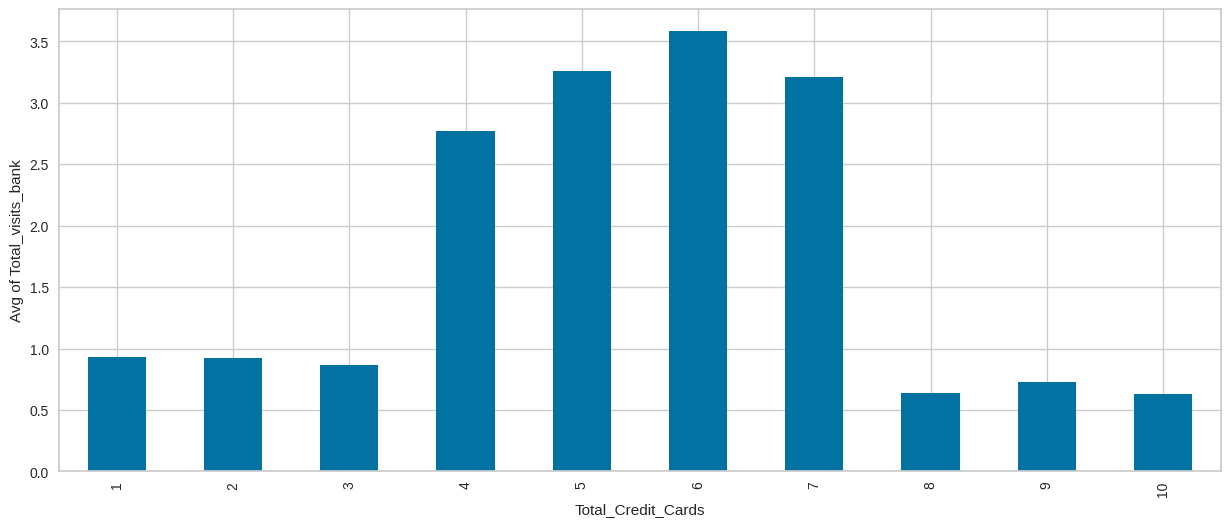

In [ ]:
df.groupby(["Total_Credit_Cards"])['Total_visits_bank'].mean().plot.bar(figsize=(15,6));
plt.xlabel('Total_Credit_Cards')
plt.ylabel('Avg of Total_visits_bank')

Text(0, 0.5, 'Avg of Total_visits_online')

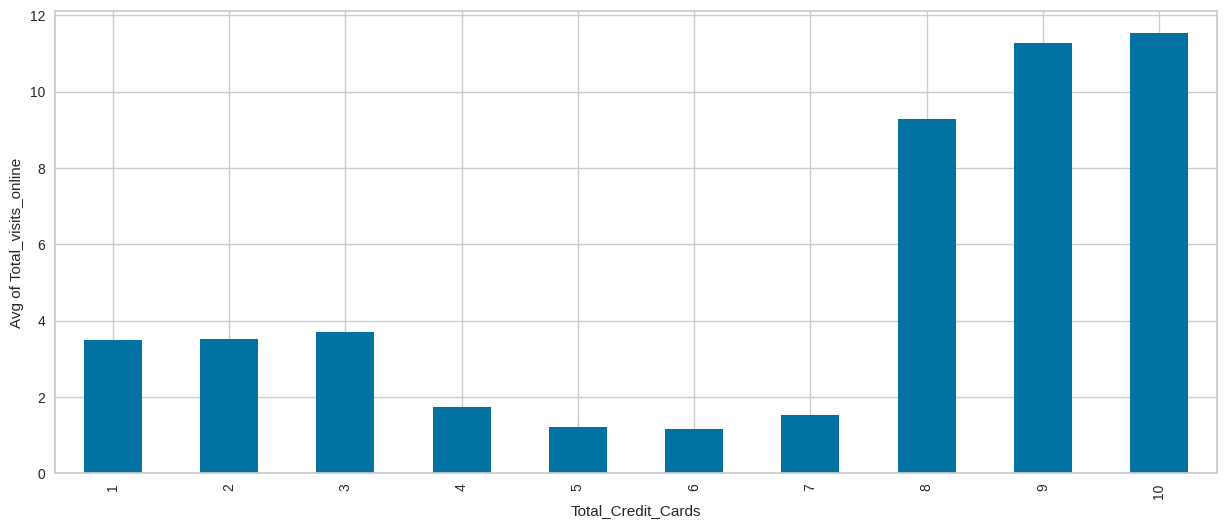

In [ ]:
df.groupby(["Total_Credit_Cards"])['Total_visits_online'].mean().plot.bar(figsize=(15,6));
plt.xlabel('Total_Credit_Cards')
plt.ylabel('Avg of Total_visits_online')


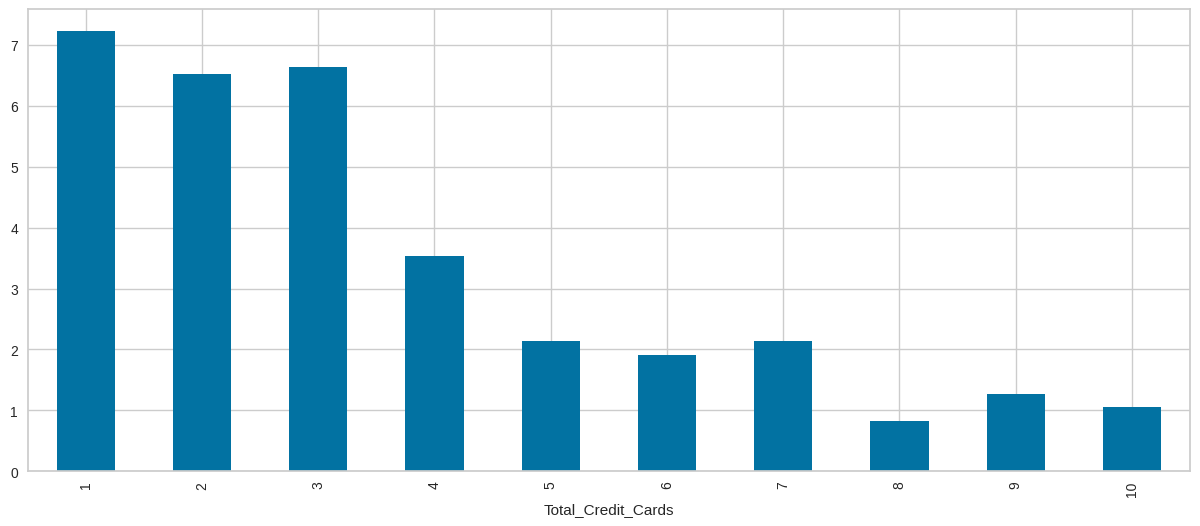

In [ ]:
df.groupby(["Total_Credit_Cards"])['Total_calls_made'].mean().plot.bar(figsize=(15,6));


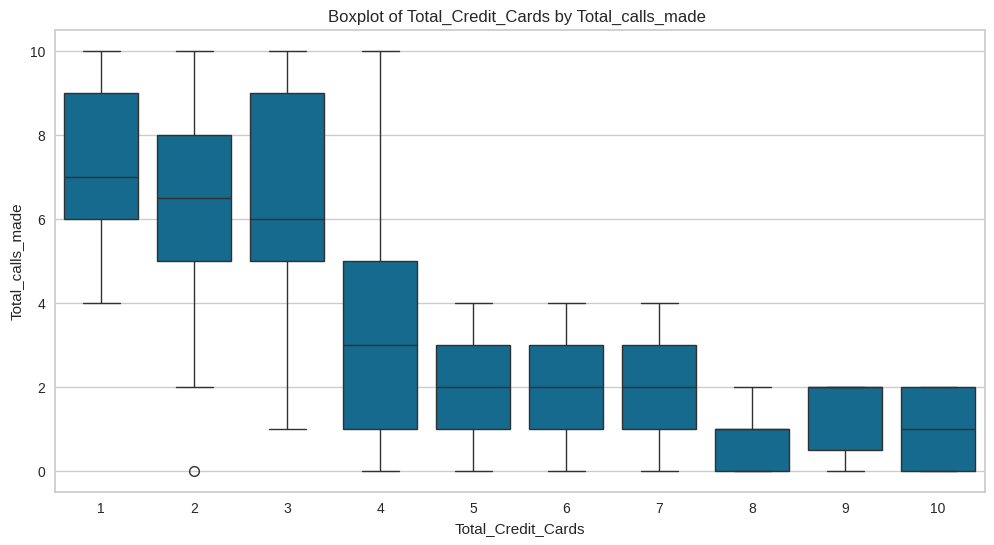

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data,x='Total_Credit_Cards',y='Total_calls_made')
plt.title('Boxplot of Total_Credit_Cards by Total_calls_made ')
plt.xlabel('Total_Credit_Cards')
plt.ylabel('Total_calls_made')
plt.show()

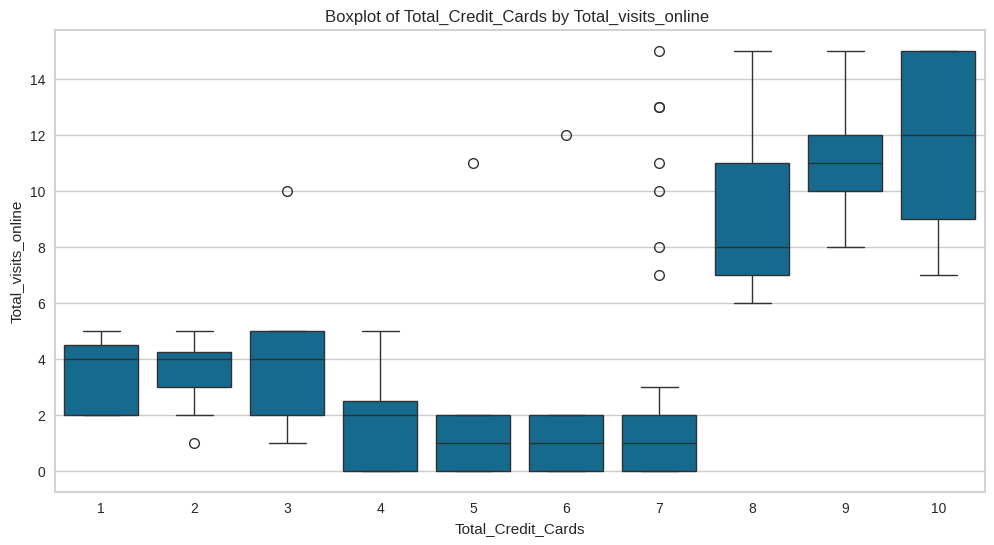

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data,x='Total_Credit_Cards',y='Total_visits_online')
plt.title('Boxplot of Total_Credit_Cards by Total_visits_online ')
plt.xlabel('Total_Credit_Cards')
plt.ylabel('Total_visits_online')
plt.show()

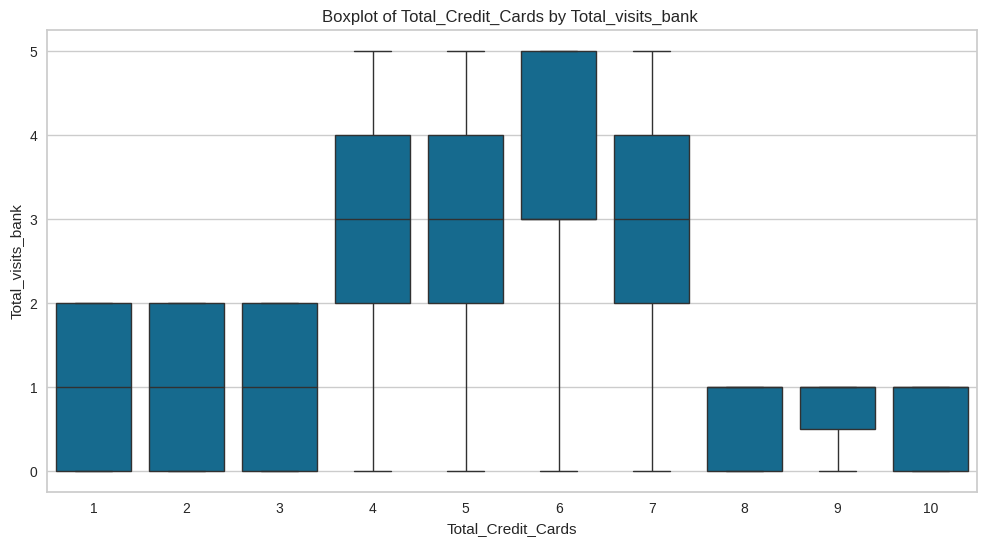

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data,x='Total_Credit_Cards',y='Total_visits_bank')
plt.title('Boxplot of Total_Credit_Cards by Total_visits_bank ')
plt.xlabel('Total_Credit_Cards')
plt.ylabel('Total_visits_bank')
plt.show()

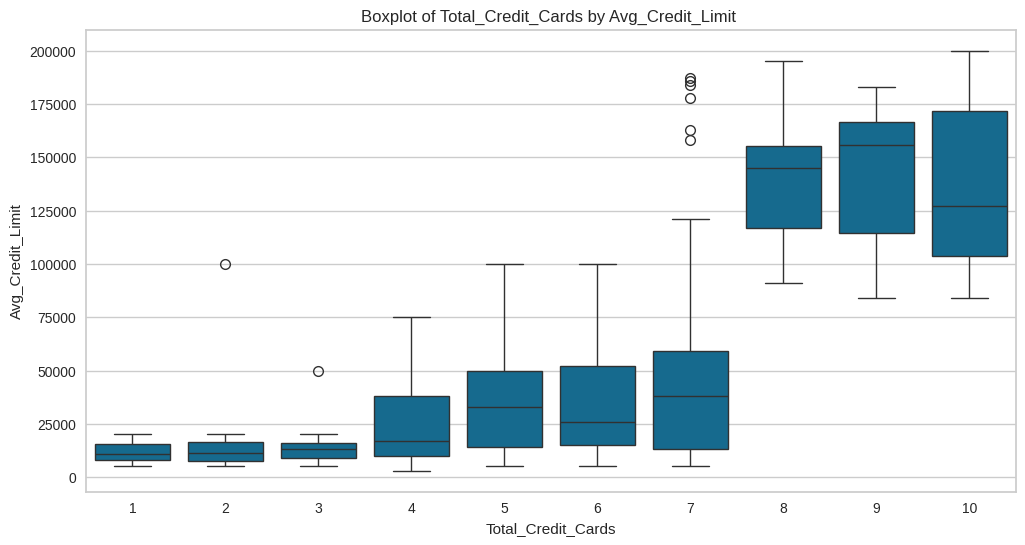

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data,x='Total_Credit_Cards',y='Avg_Credit_Limit')
plt.title('Boxplot of Total_Credit_Cards by Avg_Credit_Limit ')
plt.xlabel('Total_Credit_Cards')
plt.ylabel('Avg_Credit_Limit')
plt.show()

#Data Preprocessing

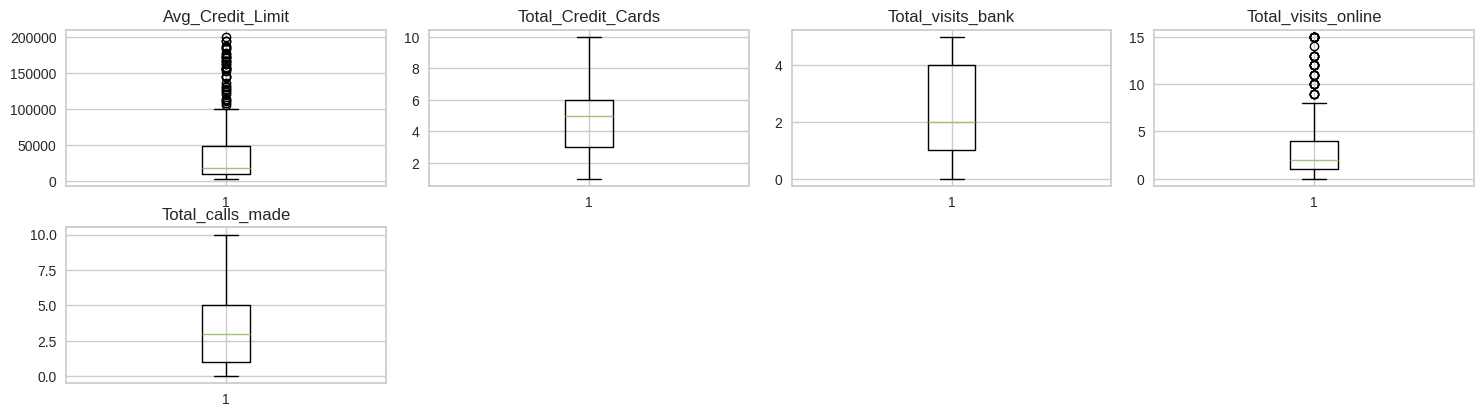

In [ ]:
plt.figure(figsize=(15, 12))

for i, variable in enumerate(df):
    plt.subplot(6, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [ ]:
# scaling the dataset before clustering
scaler = StandardScaler()
subset = df.copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
df_scaled = pd.DataFrame(subset_scaled, columns=subset.columns)

In [ ]:
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.767076,-1.241704,-0.858568,-0.546642,-1.257006
1,0.423440,-0.780379,-1.471163,2.516526,1.884177
2,0.423440,1.064922,-0.858568,0.134062,0.139075
3,-0.114014,0.142271,-0.858568,-0.546642,0.139075
4,1.767076,0.603597,-1.471163,3.197230,-0.209945


# **K-means Clustering**

Number of Clusters: 1 	Average Distortion: 2.006682556741067
Number of Clusters: 2 	Average Distortion: 1.4554607273975229
Number of Clusters: 3 	Average Distortion: 1.145871537548017
Number of Clusters: 4 	Average Distortion: 1.0467464299391422
Number of Clusters: 5 	Average Distortion: 1.0280011612293138
Number of Clusters: 6 	Average Distortion: 0.9503912931110545
Number of Clusters: 7 	Average Distortion: 0.9208371513207894
Number of Clusters: 8 	Average Distortion: 0.902711874951841


Text(0.5, 1.0, 'Selecting k with the Elbow Method')

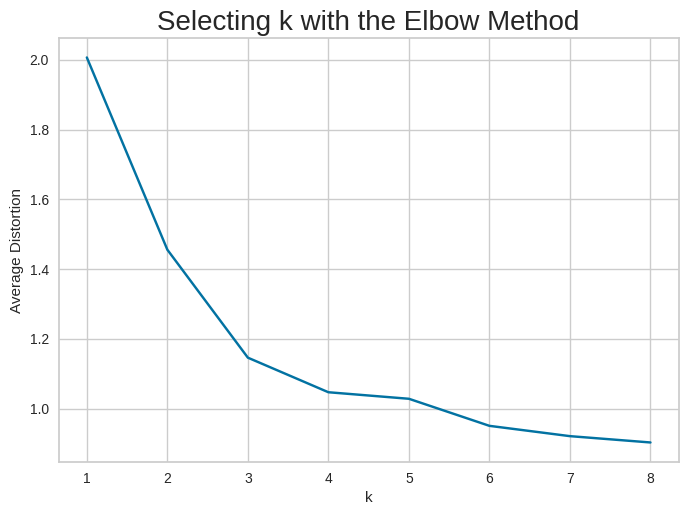

In [ ]:
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(df_scaled)
    prediction = model.predict(df_scaled)
    distortion = (
        sum(
            np.min(cdist(df_scaled, model.cluster_centers_, "euclidean"), axis=1)
        )
        / df_scaled.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)

#Silhouette Score Check

In [ ]:
sil_score = []
cluster_list = list(range(2,10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((df_scaled))
    #centers = clusterer.cluster_centers_
    score = silhouette_score(df_scaled, preds)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.4186065257549025)
For n_clusters = 3, silhouette score is 0.5154145560843687)
For n_clusters = 4, silhouette score is 0.3550820814050133)
For n_clusters = 5, silhouette score is 0.27290826109091937)
For n_clusters = 6, silhouette score is 0.24436688474277943)
For n_clusters = 7, silhouette score is 0.24818439046903154)
For n_clusters = 8, silhouette score is 0.21992116263439873)
For n_clusters = 9, silhouette score is 0.2143015597025951)


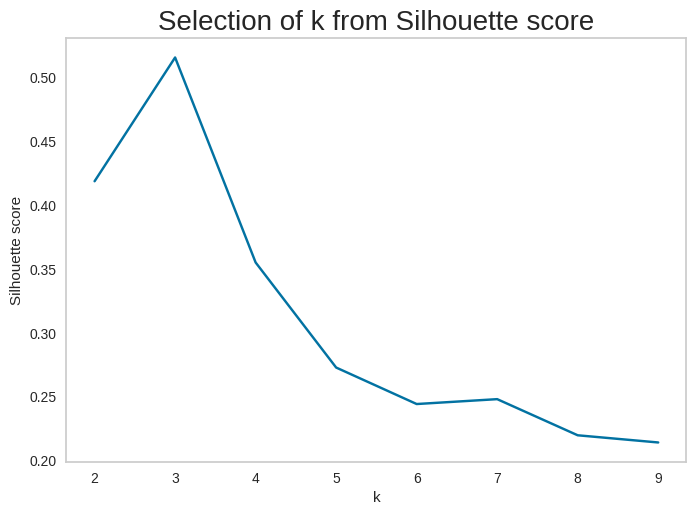

In [ ]:
plt.plot(cluster_list,sil_score)
plt.grid()
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Selection of k from Silhouette score', fontsize=20);

From the silhouette scores, it seems that 3 is a good value of k.

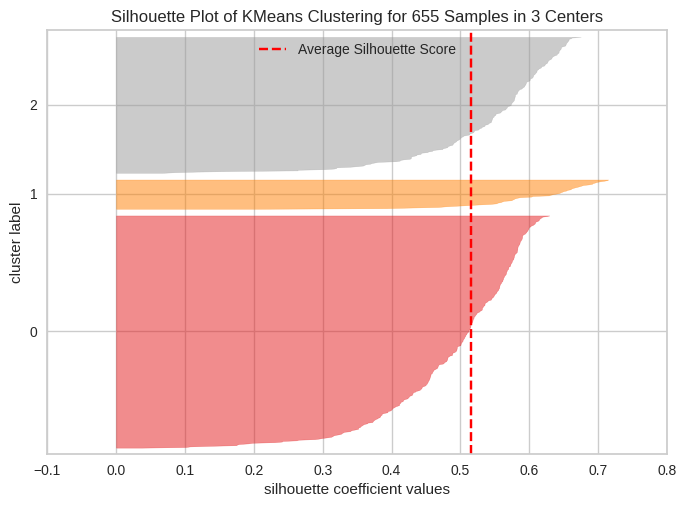

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 655 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:

visualizer = SilhouetteVisualizer(KMeans(3,random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

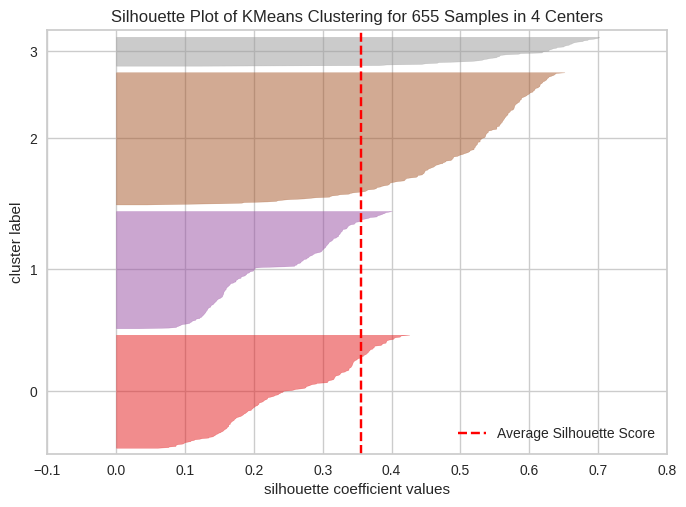

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 655 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:

visualizer = SilhouetteVisualizer(KMeans(4,random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

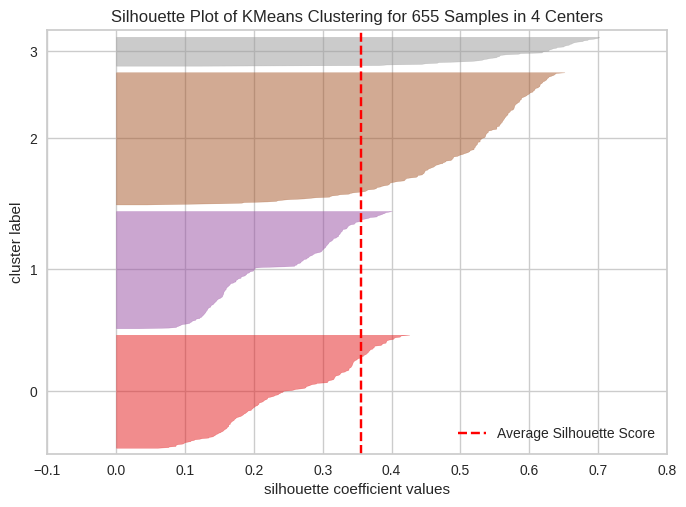

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 655 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:

visualizer = SilhouetteVisualizer(KMeans(4,random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df_scaled)

KMeans(n_clusters=3, random_state=0)

In [ ]:
df['K_means_segments'] = kmeans.labels_
df_scaled['K_means_segments'] = kmeans.labels_

In [ ]:
df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments
0,100000,2,1,1,0,0
1,50000,3,0,10,9,2
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
4,100000,6,0,12,3,1


In [ ]:
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments
0,1.767076,-1.241704,-0.858568,-0.546642,-1.257006,0
1,0.423440,-0.780379,-1.471163,2.516526,1.884177,2
2,0.423440,1.064922,-0.858568,0.134062,0.139075,0
3,-0.114014,0.142271,-0.858568,-0.546642,0.139075,0
4,1.767076,0.603597,-1.471163,3.197230,-0.209945,1


#Cluster Profiling

In [ ]:
cluster_profile = df.groupby("K_means_segments").mean(numeric_only = True)

In [ ]:
cluster_profile['count_in_each_segment'] = df.groupby('K_means_segments')['Total_Credit_Cards'].count().values


In [ ]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
K_means_segments,,,,,,
0,33604.712042,5.505236,3.494764,0.976440,2.005236,382
1,140102.040816,8.775510,0.591837,10.979592,1.102041,49
2,12174.107143,2.410714,0.933036,3.553571,6.870536,224


In [ ]:
Clust = df.groupby(['K_means_segments'])
Clust.mean()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
K_means_segments,,,,,
0,33604.712042,5.505236,3.494764,0.976440,2.005236
1,140102.040816,8.775510,0.591837,10.979592,1.102041
2,12174.107143,2.410714,0.933036,3.553571,6.870536


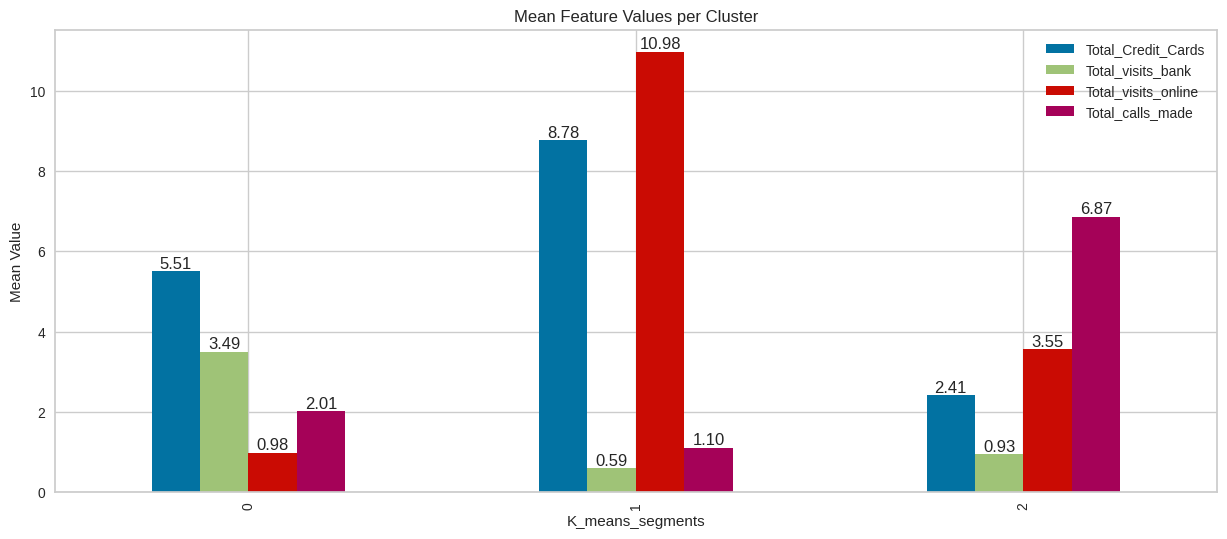

In [ ]:
ax = df.iloc[:,1:].groupby('K_means_segments').mean().plot.bar(figsize=(15,6));
plt.xlabel('K_means_segments')
plt.ylabel('Mean Value')
plt.title('Mean Feature Values per Cluster')

# Add annotations to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')

plt.show()

In [ ]:
cluster_counts = df['K_means_segments'].value_counts().sort_index()
print("Number of members in each cluster:")
print(cluster_counts)

Number of members in each cluster:
K_means_segments
0    382
1     49
2    224
Name: count, dtype: int64


In [ ]:
cluster_0_data = df[df['K_means_segments'] == 0]

print("Minimum values for Cluster 0:")
print(cluster_0_data.min())

print("\nMaximum values for Cluster 0:")
print(cluster_0_data.max())

Minimum values for Cluster 0:
Avg_Credit_Limit       5000
Total_Credit_Cards        2
Total_visits_bank         1
Total_visits_online       0
Total_calls_made          0
K_means_segments          0
dtype: int64

Maximum values for Cluster 0:
Avg_Credit_Limit       100000
Total_Credit_Cards          7
Total_visits_bank           5
Total_visits_online         3
Total_calls_made            4
K_means_segments            0
dtype: int64


In [ ]:
cluster_1_data = df[df['K_means_segments'] == 1]

print("Minimum values for Cluster 1:")
print(cluster_1_data.min())

print("\nMaximum values for Cluster 1:")
print(cluster_1_data.max())

Minimum values for Cluster 1:
Avg_Credit_Limit       84000
Total_Credit_Cards         5
Total_visits_bank          0
Total_visits_online        6
Total_calls_made           0
K_means_segments           1
dtype: int64

Maximum values for Cluster 1:
Avg_Credit_Limit       200000
Total_Credit_Cards         10
Total_visits_bank           1
Total_visits_online        15
Total_calls_made            3
K_means_segments            1
dtype: int64


In [ ]:
cluster_2_data = df[df['K_means_segments'] == 2]

print("Minimum values for Cluster 2:")
print(cluster_2_data.min())

print("\nMaximum values for Cluster 2:")
print(cluster_2_data.max())

Minimum values for Cluster 2:
Avg_Credit_Limit       3000
Total_Credit_Cards        1
Total_visits_bank         0
Total_visits_online       1
Total_calls_made          1
K_means_segments          2
dtype: int64

Maximum values for Cluster 2:
Avg_Credit_Limit       50000
Total_Credit_Cards         4
Total_visits_bank          2
Total_visits_online       10
Total_calls_made          10
K_means_segments           2
dtype: int64


In [ ]:
pd.crosstab(df.K_means_segments, df.Total_Credit_Cards)

Total_Credit_Cards,1,2,3,4,5,6,7,8,9,10
K_means_segments,,,,,,,,,,
0,0,1,0,102,73,114,92,0,0,0
1,0,0,0,0,1,1,6,11,11,19
2,59,63,53,49,0,0,0,0,0,0


In [ ]:
pd.crosstab(df.K_means_segments,df.Total_visits_bank)

Total_visits_bank,0,1,2,3,4,5
K_means_segments,,,,,,
0,0,3,91,99,92,97
1,20,29,0,0,0,0
2,80,79,65,0,0,0


In [ ]:
pd.crosstab(df.K_means_segments,df.Total_visits_online)

Total_visits_online,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
K_means_segments,,,,,,,,,,,,,,,,
0,144,104,133,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,6,6,4,5,5,6,5,1,10
2,0,3,54,43,69,54,0,0,0,0,1,0,0,0,0,0


In [ ]:
pd.crosstab(df.K_means_segments,df.Total_calls_made)

Total_calls_made,0,1,2,3,4,5,6,7,8,9,10
K_means_segments,,,,,,,,,,,
0,80,74,69,82,77,0,0,0,0,0,0
1,15,15,18,1,0,0,0,0,0,0,0
2,0,1,1,0,31,29,39,35,30,32,26


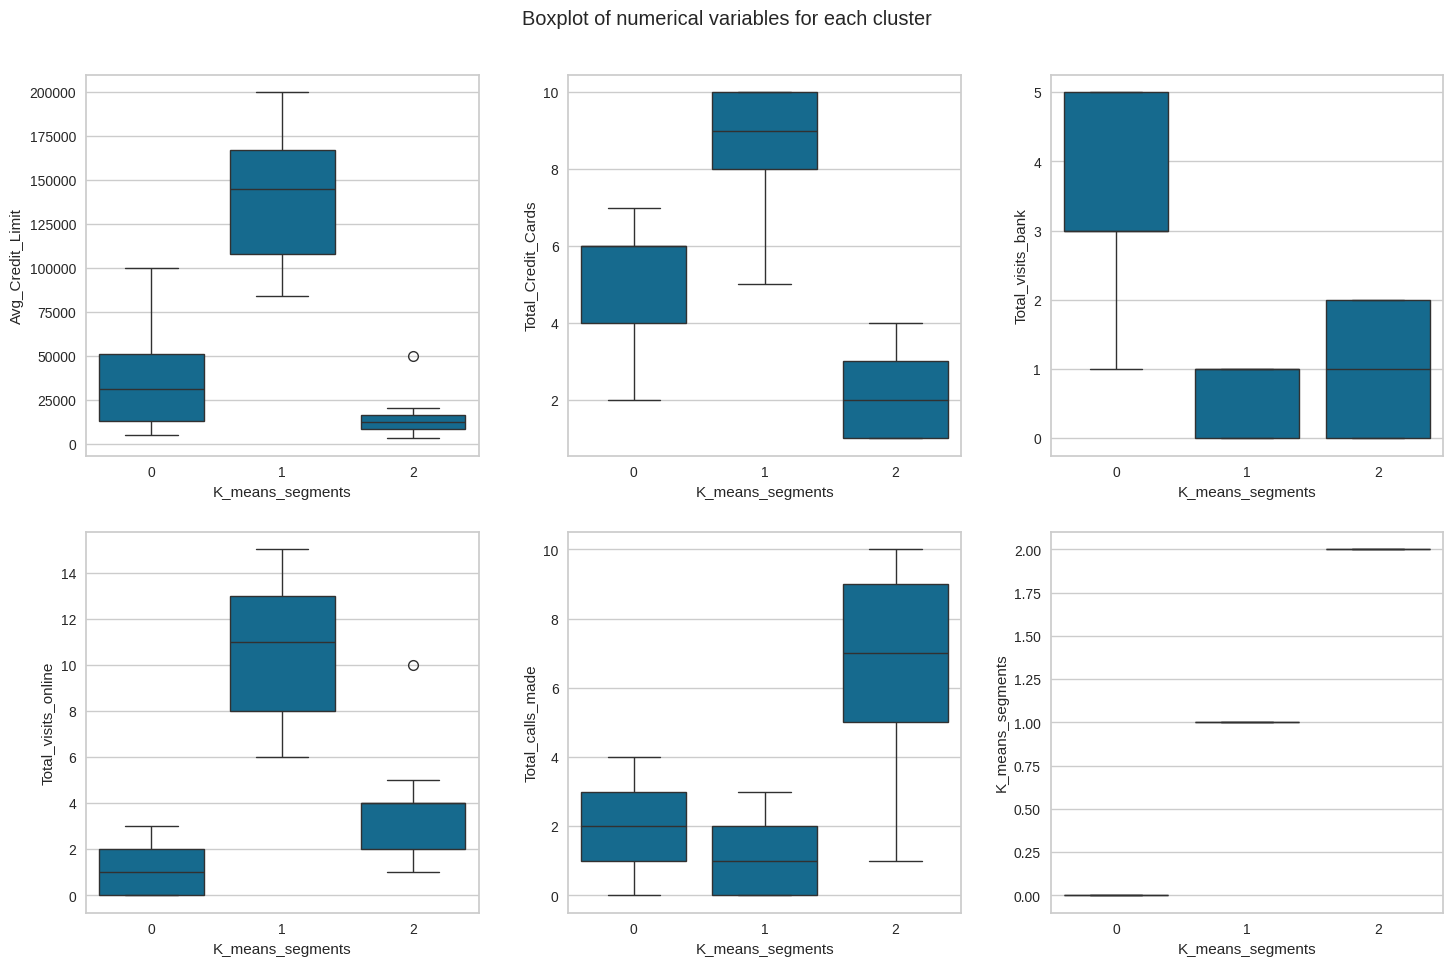

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(df):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df, x="K_means_segments", y=variable)

plt.tight_layout(pad=2.0)

# **Hierarchial Clustering**

In [ ]:
df2_scaled = df_scaled.drop('K_means_segments',axis=1).copy()
df2=df.drop('K_means_segments',axis=1).copy()

# Checking Cophenetic Correlation

In [ ]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(df2_scaled, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(df2_scaled))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.7392346514952489.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8672981179730402.
Cophenetic correlation for Euclidean distance and average linkage is 0.8978684505898265.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8923308120540114.
Cophenetic correlation for Chebyshev distance and single linkage is 0.7396083723472703.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.851859158487362.
Cophenetic correlation for Chebyshev distance and average linkage is 0.896046402728589.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8714371082036658.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.7050670931967605.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.6561090581872261.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8318830598319873.
Cophenetic corr

In [ ]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8978684505898265, which is obtained with Euclidean distance and average linkage.



Let's explore different linkage methods with Euclidean distance only.

In [ ]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(df2_scaled, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(df2_scaled))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.7392346514952489.
Cophenetic correlation for complete linkage is 0.8672981179730402.
Cophenetic correlation for average linkage is 0.8978684505898265.
Cophenetic correlation for centroid linkage is 0.894036986651765.
Cophenetic correlation for ward linkage is 0.7392392076250658.
Cophenetic correlation for weighted linkage is 0.8923308120540114.


In [ ]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8978684505898265, which is obtained with average linkage.


# Checking Dendrograms

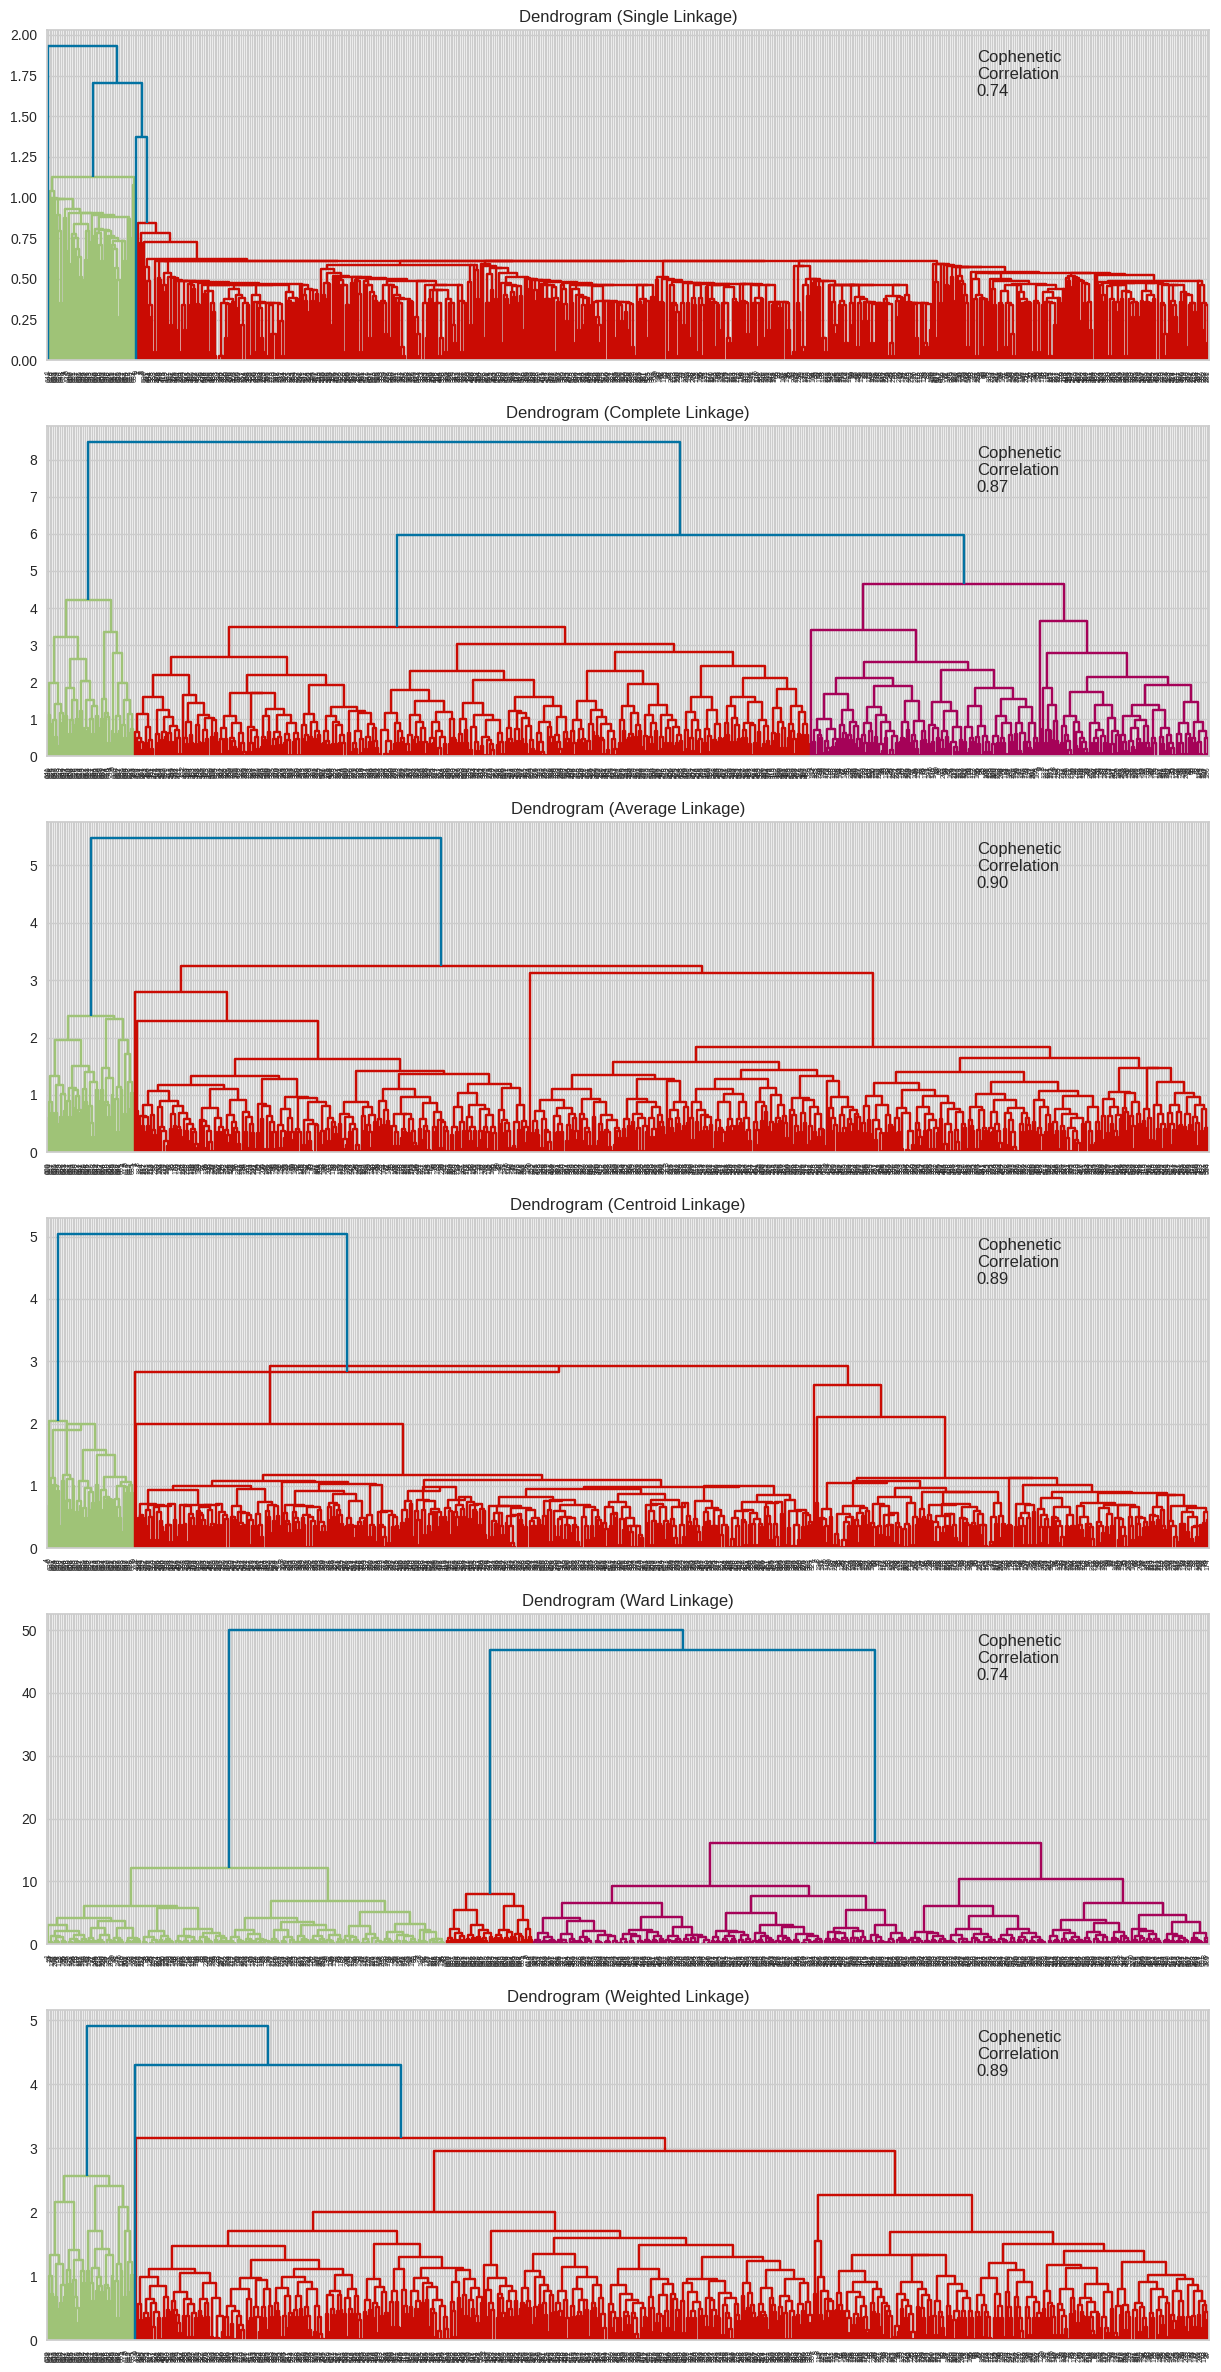

In [ ]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(df2_scaled, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(df2_scaled))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

# Creating Model using sklearn

In [ ]:
HCmodel = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="average")
HCmodel.fit(df2_scaled)

AgglomerativeClustering(linkage='average', n_clusters=3)

In [ ]:
df2_scaled["HC_Clusters"] = HCmodel.labels_
df2["HC_Clusters"] = HCmodel.labels_

In [ ]:
df2.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,HC_Clusters
0,100000,2,1,1,0,0
1,50000,3,0,10,9,2
2,50000,7,1,3,4,0
3,30000,5,1,1,4,0
4,100000,6,0,12,3,1


# Cluster Profiling

In [ ]:
cluster_profile = df2.groupby("HC_Clusters").mean(numeric_only = True)

In [ ]:
cluster_profile['counts_in_each_segment'] = df2.groupby('HC_Clusters')['Total_Credit_Cards'].count().values

In [ ]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,counts_in_each_segment
HC_Clusters,,,,,,
0,33535.248042,5.501305,3.490862,0.979112,2.010444,383
1,140102.040816,8.775510,0.591837,10.979592,1.102041,49
2,12197.309417,2.403587,0.928251,3.560538,6.883408,223


In [ ]:
Clust1 = df2.groupby(['HC_Clusters'])
Clust1.mean()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
HC_Clusters,,,,,
0,33535.248042,5.501305,3.490862,0.979112,2.010444
1,140102.040816,8.775510,0.591837,10.979592,1.102041
2,12197.309417,2.403587,0.928251,3.560538,6.883408


In [ ]:
cluster_0_data = df2[df2['HC_Clusters'] == 0]

print("Minimum values for Cluster 0:")
print(cluster_0_data.min())

print("\nMaximum values for Cluster 0:")
print(cluster_0_data.max())

Minimum values for Cluster 0:
Avg_Credit_Limit       5000
Total_Credit_Cards        2
Total_visits_bank         1
Total_visits_online       0
Total_calls_made          0
HC_Clusters               0
dtype: int64

Maximum values for Cluster 0:
Avg_Credit_Limit       100000
Total_Credit_Cards          7
Total_visits_bank           5
Total_visits_online         3
Total_calls_made            4
HC_Clusters                 0
dtype: int64


In [ ]:
cluster_1_data = df2[df2['HC_Clusters'] == 1]

print("Minimum values for Cluster 1:")
print(cluster_1_data.min())

print("\nMaximum values for Cluster 1:")
print(cluster_1_data.max())

Minimum values for Cluster 1:
Avg_Credit_Limit       84000
Total_Credit_Cards         5
Total_visits_bank          0
Total_visits_online        6
Total_calls_made           0
HC_Clusters                1
dtype: int64

Maximum values for Cluster 1:
Avg_Credit_Limit       200000
Total_Credit_Cards         10
Total_visits_bank           1
Total_visits_online        15
Total_calls_made            3
HC_Clusters                 1
dtype: int64


In [ ]:
cluster_2_data = df2[df2['HC_Clusters'] == 2]

print("Minimum values for Cluster 2:")
print(cluster_2_data.min())

print("\nMaximum values for Cluster 1:")
print(cluster_2_data.max())

Minimum values for Cluster 2:
Avg_Credit_Limit       3000
Total_Credit_Cards        1
Total_visits_bank         0
Total_visits_online       1
Total_calls_made          1
HC_Clusters               2
dtype: int64

Maximum values for Cluster 1:
Avg_Credit_Limit       50000
Total_Credit_Cards         4
Total_visits_bank          2
Total_visits_online       10
Total_calls_made          10
HC_Clusters                2
dtype: int64


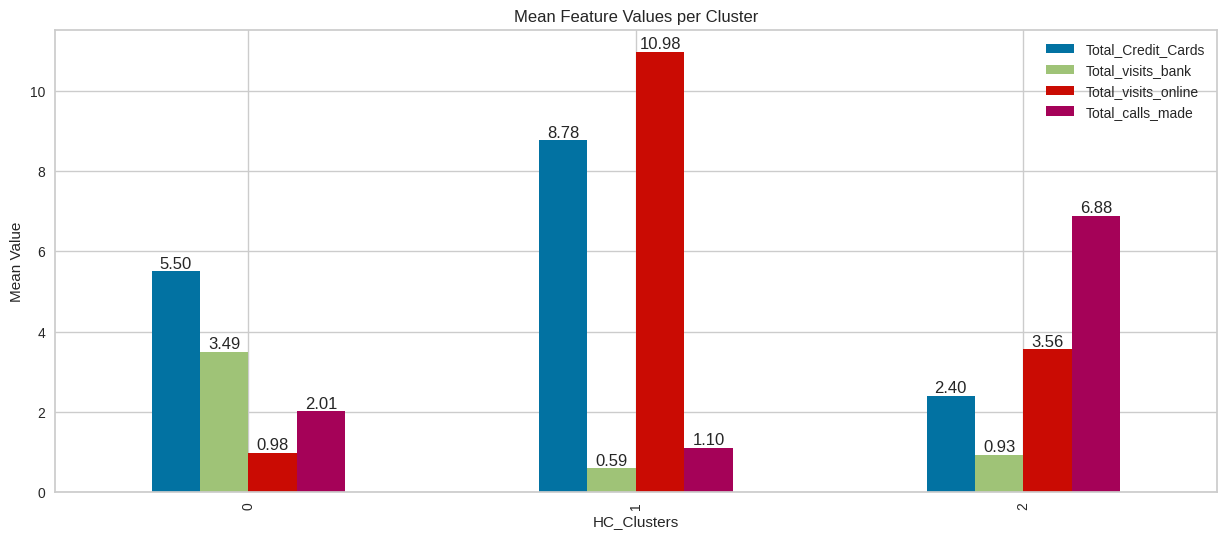

In [ ]:
ax = df2.iloc[:,1:].groupby('HC_Clusters').mean().plot.bar(figsize=(15,6));
plt.xlabel('HC_Clusters')
plt.ylabel('Mean Value')
plt.title('Mean Feature Values per Cluster')

# Add annotations to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')

plt.show()

In [ ]:
pd.crosstab(df2.HC_Clusters, df2.Total_Credit_Cards)

Total_Credit_Cards,1,2,3,4,5,6,7,8,9,10
HC_Clusters,,,,,,,,,,
0,0,1,0,103,73,114,92,0,0,0
1,0,0,0,0,1,1,6,11,11,19
2,59,63,53,48,0,0,0,0,0,0


In [ ]:
pd.crosstab(df2.HC_Clusters, df2.Total_visits_bank)

Total_visits_bank,0,1,2,3,4,5
HC_Clusters,,,,,,
0,0,3,92,99,92,97
1,20,29,0,0,0,0
2,80,79,64,0,0,0


In [ ]:
pd.crosstab(df2.HC_Clusters, df2.Total_visits_online)

Total_visits_online,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
HC_Clusters,,,,,,,,,,,,,,,,
0,144,104,134,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,6,6,4,5,5,6,5,1,10
2,0,3,53,43,69,54,0,0,0,0,1,0,0,0,0,0


In [ ]:
pd.crosstab(df2.HC_Clusters, df2.Total_calls_made)

Total_calls_made,0,1,2,3,4,5,6,7,8,9,10
HC_Clusters,,,,,,,,,,,
0,80,74,69,82,78,0,0,0,0,0,0
1,15,15,18,1,0,0,0,0,0,0,0
2,0,1,1,0,30,29,39,35,30,32,26


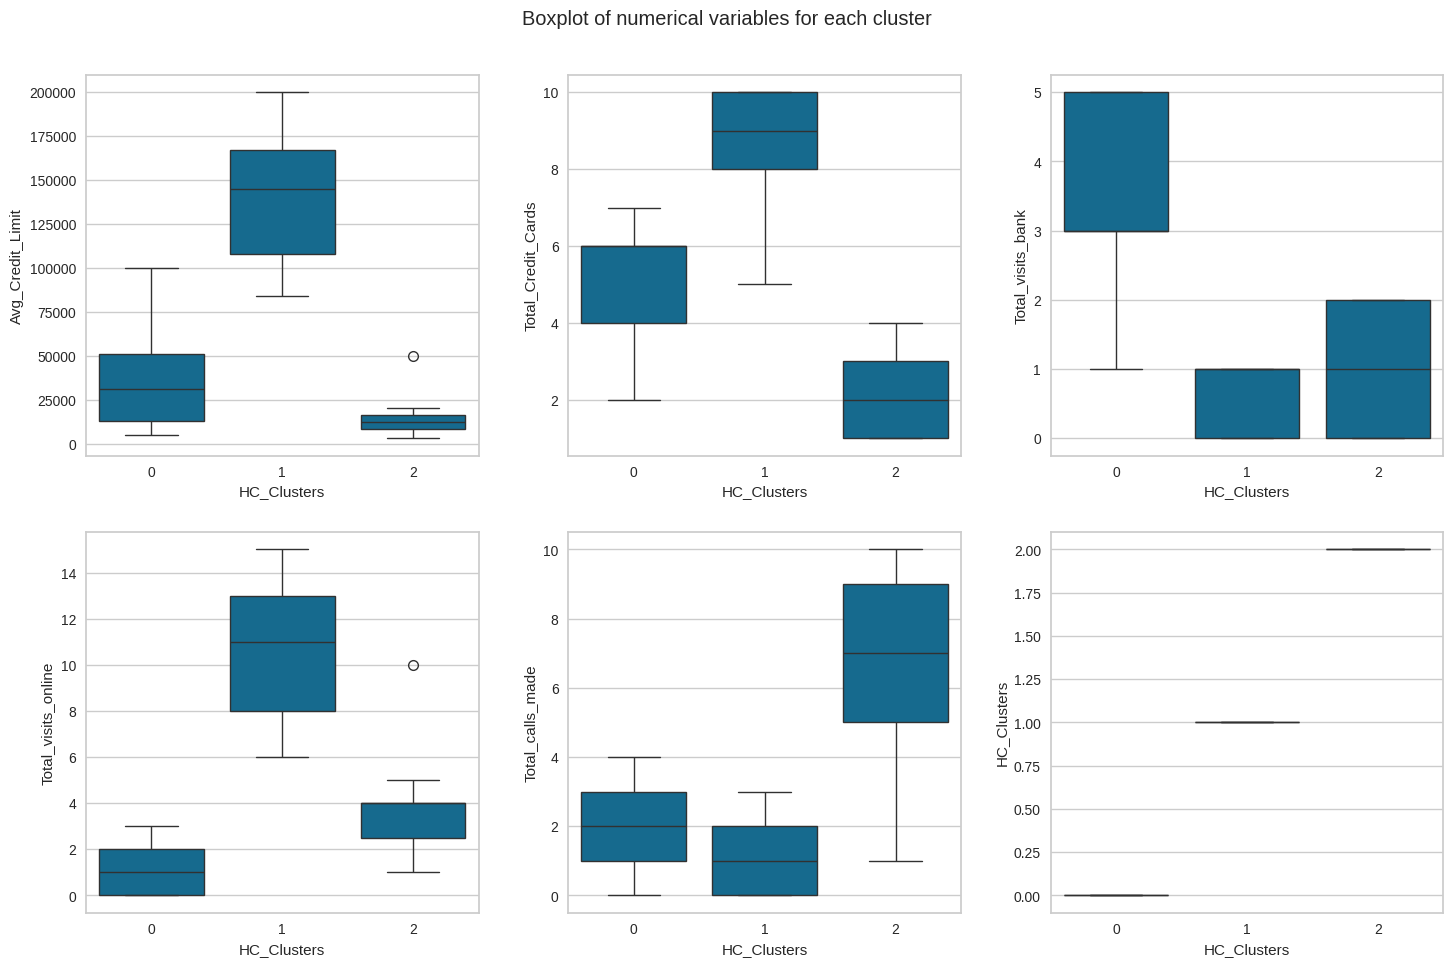

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(df2):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df2, x="HC_Clusters", y=variable)

plt.tight_layout(pad=2.0)